# 05 · Segmentation, baseline and quality control

**ROBT613 · Brain–Computer Interfaces** | 90–120 min

## Goal
Build event-locked epochs from continuous EEG, audit discarded trials and preserve run identity.

**Data:** MNE EEGBCI subject 1, run 4

Run cells from top to bottom in a fresh CPU runtime. No previous notebook state is required.

## Setup
The first cell installs the tested core versions in Colab. Downloads are cached in `mne_data/`; a new Colab runtime loses that cache. A failed download is an error, never silently replaced by synthetic data.

In [1]:
# Colab: install before importing numerical libraries. Restart if pip requests it.
import sys, subprocess, os
if 'google.colab' in sys.modules:
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q',
                           'mne==1.13.2', 'moabb==1.7.2'])
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import mne
from scipy import signal
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (balanced_accuracy_score, roc_auc_score,
                             ConfusionMatrixDisplay, classification_report)
from sklearn.model_selection import (GroupKFold, cross_validate, GridSearchCV)
SEED = 613
rng = np.random.default_rng(SEED)
DATA_ROOT = Path(os.environ.get('BCI_DATA', './mne_data')).resolve()
DATA_ROOT.mkdir(parents=True, exist_ok=True)
os.environ['MNE_DATA'] = str(DATA_ROOT)
mne.set_log_level('WARNING')
plt.rcParams.update({'figure.figsize': (9, 4), 'font.size': 11,
                     'axes.spines.top': False, 'axes.spines.right': False})
import importlib.metadata as metadata
print({p: metadata.version(p) for p in ['mne','moabb','numpy','scipy','scikit-learn']})
print('Dataset cache:', DATA_ROOT)

{'mne': '1.13.2', 'moabb': '1.7.2', 'numpy': '2.1.3', 'scipy': '1.15.3', 'scikit-learn': '1.6.1'}
Dataset cache: ./mne_data


## Concepts and mathematics

A cue at sample $s_i$ becomes an epoch $X_i[:,n]=x[:,s_i+n]$ over a specified interval. Event latency is part of the measurement: stimulus display delay and clock drift cannot be corrected by classification. MNE accounts for `raw.first_samp`; do not subtract it twice.

Baseline correction is $X_i'(c,t)=X_i(c,t)-|B|^{-1}\sum_{u\in B}X_i(c,u)$. It assumes the reference interval is appropriate and can propagate baseline noise across the full trial. Motor imagery decoding often uses bandpassed post-cue power without ERP baseline subtraction. Peak-to-peak rejection removes an epoch when $\max_t X_i(c,t)-\min_t X_i(c,t)>\theta_c$.

Rejection changes the analyzed population. Report counts before and after, by class and run, and separate boundary drops from amplitude drops. Overlapping sliding windows from one trial must remain in one split group. Preserve subject, session, run and original trial identifiers before any concatenation.

## Parse annotations explicitly
The T1/T2 mapping depends on the run. Run 4 is imagined left/right fist.

In [2]:
from mne.datasets import eegbci
files = eegbci.load_data(1, [4], path=DATA_ROOT, update_path=False)
raw = mne.io.read_raw_edf(files[0], preload=True, verbose=False)
eegbci.standardize(raw)
raw.set_montage('standard_1005')
print(raw)
print('Channel types:', set(raw.get_channel_types()))

events,event_id=mne.events_from_annotations(raw,event_id={'T1':1,'T2':2})
print(event_id, events[:5])
raw.filter(1,30)
base = mne.Epochs(raw,events,{'left':1,'right':2},-.5,3.5,
                  baseline=None,preload=True,picks='eeg',reject_by_annotation=True)
print('Candidate events:',len(events),'in-bounds epochs:',len(base))

/tmp/ipykernel_418515/922569553.py:5: FutureWarning: Montage name 'standard_1005' is deprecated and will be removed in MNE 1.14. Use 'colin27_1005' instead.
  raw.set_montage('standard_1005')


<RawEDF | S001R04.edf, 64 x 20000 (125.0 s), ~9.8 MiB, data loaded>
Channel types: {'eeg'}


{'T1': 1, 'T2': 2} [[ 672    0    2]
 [2000    0    1]
 [3328    0    1]
 [4656    0    2]
 [5984    0    2]]
Candidate events: 15 in-bounds epochs: 15


## Reject and audit
The threshold is a declared teaching choice, not a universal EEG quality standard.

   class  before  after  removed
0   left       8      8        0
1  right       7      4        3
Drop reasons: (('Fp1', 'AF7', 'AF3'), (), (), (), (), (), ('Fp1', 'Fpz', 'Fp2', 'AF8'), ())


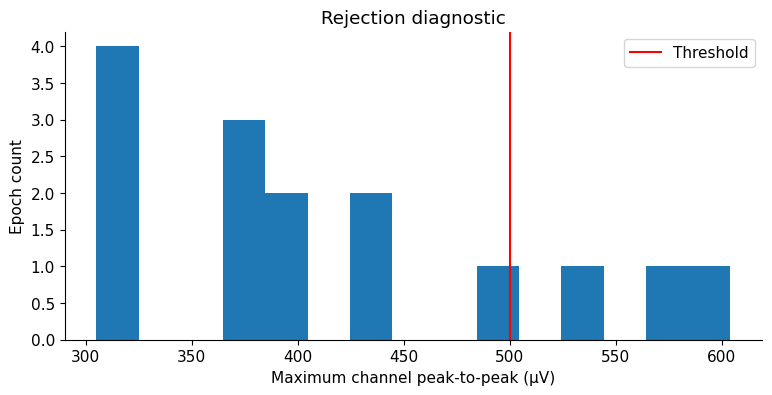

In [3]:
threshold = 500e-6
checked = base.copy().drop_bad(reject={'eeg':threshold})
rows=[]
for name,event in base.event_id.items():
    before=np.sum(base.events[:,2]==event)
    after=np.sum(checked.events[:,2]==event)
    rows.append({'class':name,'before':int(before),'after':int(after),'removed':int(before-after)})
print(pd.DataFrame(rows))
print('Drop reasons:', checked.drop_log[:8])
assert len(checked)<=len(base)
fig,ax=plt.subplots()
ax.hist(np.ptp(base.get_data(),axis=-1).max(axis=1)*1e6,bins=15)
ax.axvline(threshold*1e6,color='red',label='Threshold')
ax.set(xlabel='Maximum channel peak-to-peak (µV)',ylabel='Epoch count',title='Rejection diagnostic')
ax.legend(); plt.show()

## Verify a baseline numerically
Use this for understanding ERP baselines, not as a mandatory motor-imagery step.

In [4]:
baseline_epochs=base.copy().apply_baseline((-.5,0))
mask=(baseline_epochs.times>=-.5)&(baseline_epochs.times<=0)
assert np.allclose(baseline_epochs.get_data()[:,:,mask].mean(-1),0,atol=1e-12)
print('Baseline mean is numerically zero.')

Baseline mean is numerically zero.


## Exercises and checks
1. Compare 75, 150 and 300 µV thresholds without selecting the threshold by test accuracy.
2. Explain what happens when the first event lacks enough pre-event data.
3. Add metadata columns for subject, run and original event sample.
4. Design split groups for 50%-overlapping windows and explain why windows are not independent trials.

## Next steps and sources
[MNE epochs](https://mne.tools/stable/auto_tutorials/epochs/10_epochs_overview.html) · [Epoch rejection](https://mne.tools/stable/auto_tutorials/preprocessing/20_rejecting_bad_data.html).

Record package versions, subject/run IDs, preprocessing, split unit, random seed, and all exclusions with your results. Do not interpret a single participant as a population estimate.